<a href="https://colab.research.google.com/github/ShakilCuambe/Pure-art/blob/main/Pure_art.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

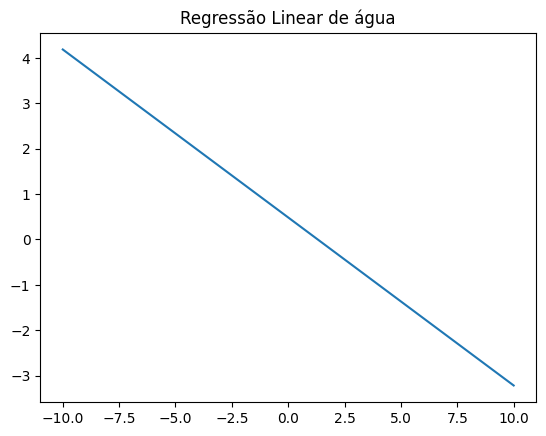

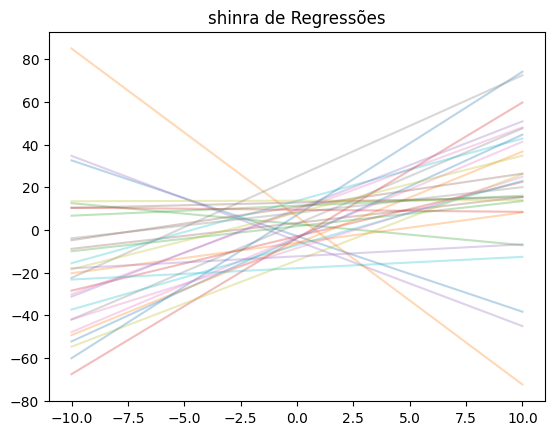

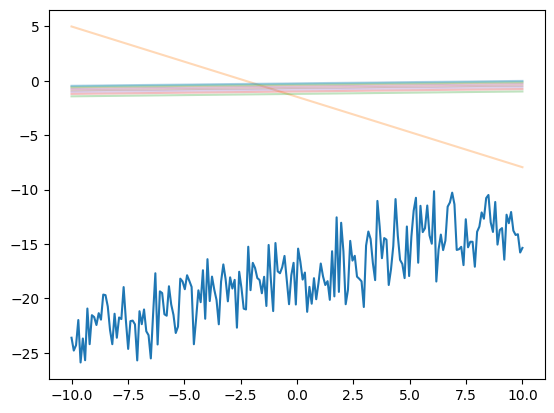

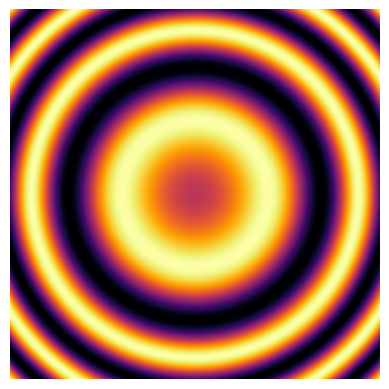

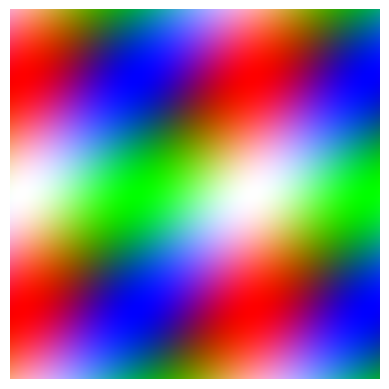

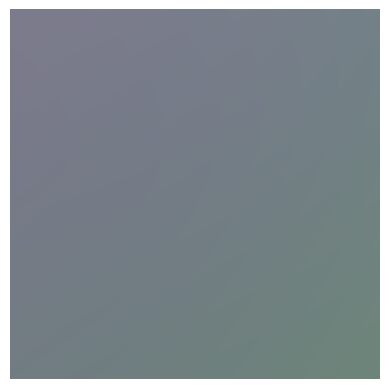

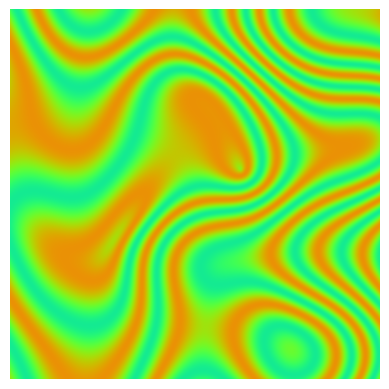

In [2]:
import torch
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


# dados
x = torch.linspace(-10, 10, 200)

# master your own art
w = torch.randn(1) * 2
b = torch.randn(1) * 5

# regressão
y = w * x + b

# plot
plt.figure()
plt.plot(x.numpy(), y.numpy())
plt.title("Regressão Linear de água")
plt.show()
plt.figure()

for i in range(30):
    w = torch.randn(1) * 3
    b = torch.randn(1) * 10
    y = w * x + b

    plt.plot(x.numpy(), y.numpy(), alpha=0.3)

plt.title("shinra de Regressões")
plt.show()

noise = torch.randn_like(x) * 2
y = w * x + b + noise

plt.plot(x.numpy(), y.numpy())
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

optimizer = torch.optim.SGD([w, b], lr=0.01)

for step in range(100):
    y_pred = w * x + b
    loss = (y_pred - torch.sin(x)).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 10 == 0:
        plt.plot(x.detach().numpy(), y_pred.detach().numpy(), alpha=0.3)

plt.show()

# resolução da imagem
H, W = 512, 512


y, x = torch.meshgrid(
    torch.linspace(-1, 1, H),
    torch.linspace(-1, 1, W),
    indexing='ij'
)

# so pure like water
z = torch.sin(10 * (x**2 + y**2))


img = (z - z.min()) / (z.max() - z.min())

plt.imshow(img.numpy(), cmap='inferno')
plt.axis('off')
plt.show()

r = torch.sin(5 * x)
g = torch.cos(5 * y)
b = torch.sin(5 * (x + y))

img = torch.stack([r, g, b], dim=-1)

# normalizar
img = (img - img.min()) / (img.max() - img.min())

plt.imshow(img.numpy())
plt.axis('off')
plt.show()

model = nn.Sequential(
    nn.Linear(2, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 3),
    nn.Sigmoid()
)

# entrada: coordenadas (x, y)
coords = torch.stack([x.flatten(), y.flatten()], dim=1)

# gera imagem
colors = model(coords)
img = colors.view(H, W, 3).detach()

plt.imshow(img.numpy())
plt.axis('off')
plt.show()



H, W = 800, 800

# grid
y, x = torch.meshgrid(
    torch.linspace(-1, 1, H),
    torch.linspace(-1, 1, W),
    indexing='ij'
)

# Distorção psicodélica (warp)
x2 = x + 0.4 * torch.sin(5 * y)
y2 = y + 0.4 * torch.cos(5 * x)


r = torch.sqrt(x2**2 + y2**2)

pattern = torch.sin(15 * r + 10 * x2)

red   = torch.sin(pattern)
green = torch.sin(pattern + 2)
blue  = torch.sin(pattern + 4)

img = torch.stack([red, green, blue], dim=-1)

# normalizar
img = (img - img.min()) / (img.max() - img.min())

plt.imshow(img.numpy())
plt.axis('off')
plt.show()